# Crypto Guardian — reproducible seven-day LSTM forecasting
## Project context and purpose
Crypto Guardian is a team-built crypto intelligence platform that received **3rd place at the AI Odyssey Hackathon by GDG SUP'COM**, documented in its [repository](https://github.com/AbderrazagB/crypto-guardian-hackathon). The platform combines fraud alerts, market sentiment, and price forecasts.

This notebook is a **new follow-up experiment**, prepared after the original hackathon. The repository's [LSTM integration](https://github.com/AbderrazagB/crypto-guardian-hackathon/blob/master/price_prediction/src/models/lstm.py) specifies a 30-observation input window and seven-value output, but the original training notebook and weights are unavailable. We therefore train a new, explicitly specified model; we do not claim to reproduce the original model's results.

**Question:** Can an LSTM improve seven-day ETH Close-price forecasts over repeating the last observed Close? We use real historical OHLCV, chronological splits, training-fitted scaling, a naive baseline, horizon-specific errors, and a disclosed failure case. Hackathon placement is a project award, not a forecast metric.

In [1]:
from pathlib import Path
import os, sys, json
import warnings

def format_warning_for_report(message, category, filename, lineno, line=None):
    """Keep warning content while omitting machine-specific directories."""
    return f'{Path(filename).name}:{lineno}: {category.__name__}: {message}\n'

warnings.formatwarning = format_warning_for_report

os.environ['KERAS_BACKEND'] = 'torch'
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler
import joblib
import torch
import keras
from keras import layers
def locate_experiment_root():
    for base in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        candidate = base / 'evaluation'
        if (candidate / 'data-sources').is_dir() and (candidate / 'run-assets').is_dir():
            return candidate
    raise FileNotFoundError('Run from this repository with its evaluation inputs present.')

EXPERIMENT_ROOT = locate_experiment_root()
sys.path.insert(0, str(EXPERIMENT_ROOT / 'notebooks'))
RUN_DIR = EXPERIMENT_ROOT / 'runs' / 'lstm'
RUN_DIR.mkdir(parents=True, exist_ok=True)
if not torch.cuda.is_available():
    raise RuntimeError('This experiment requires the requested CUDA GPU.')
torch.set_num_threads(4)
keras.utils.set_random_seed(42)
print('Python executable:', Path(sys.executable).name)
print('Keras:', keras.__version__, 'backend:', keras.backend.backend())
print('GPU:', torch.cuda.get_device_name(0))

Python executable: python
Keras: 3.15.1 backend: torch
GPU: NVIDIA RTX A3000 12GB Laptop GPU


## Data and target
Use the saved Yahoo chart response for **ETH-USD daily OHLCV from 2018 through 2025**. The retrieval URL and checksum are recorded in `run-assets/lstm-history/manifest.json`. Prices are provider-defined USD daily observations, not executable quotes. Missing/nonfinite rows are reported and dropped; we never interpolate from future prices.

Inputs are named Open, High, Low, Close, and Volume. Target: the next seven observed daily Close values. Days are identified by actual data dates, rather than a stock-market weekday calendar.

In [2]:
from datetime import datetime, timezone
raw = json.loads((EXPERIMENT_ROOT / 'run-assets' / 'lstm-history' / 'ETH-USD.json').read_text())
result = raw['chart']['result'][0]
quote = result['indicators']['quote'][0]
frame = pd.DataFrame({
    'date': [datetime.fromtimestamp(t, tz=timezone.utc).strftime('%Y-%m-%d') for t in result['timestamp']],
    'Open': quote['open'], 'High': quote['high'], 'Low': quote['low'],
    'Close': quote['close'], 'Volume': quote['volume'],
})
frame['date'] = pd.to_datetime(frame['date'])
# The provider returned an extra boundary observation; enforce the requested interval.
frame = frame.loc[(frame['date'] >= '2018-01-01') & (frame['date'] < '2026-01-01')].copy()
FEATURES = ['Open', 'High', 'Low', 'Close', 'Volume']
print('Missing values before cleaning:')
display(frame[FEATURES].isna().sum().to_frame('missing'))
frame = frame.replace([np.inf, -np.inf], np.nan).dropna().sort_values('date').set_index('date')
assert not frame.index.has_duplicates and (frame['Close'] > 0).all()
if not frame.index.to_series().diff().dropna().eq(pd.Timedelta(days=1)).all():
    raise ValueError('Daily data has gaps; review them before constructing fixed-day windows.')
print('Clean rows:', len(frame), 'coverage:', frame.index.min(), 'to', frame.index.max())

Missing values before cleaning:


,missing
Open,0
High,0
Low,0
Close,0
Volume,0


Clean rows: 2922 coverage: 2018-01-01 00:00:00 to 2025-12-31 00:00:00


## Split before fitting the scaler
Training targets end before **2023-01-01**. Validation targets span **2023–2024**. Final test targets are in **2025**. All seven target dates of a window must lie within its assigned period; windows straddling a boundary are excluded. Inputs may use already observed history from the preceding period, which is available at the forecast origin.

The scaler fits only observations before 2023. Early stopping uses validation loss. Neither model architecture nor thresholds are chosen by inspecting final-test performance. Overlapping windows are correlated, so window counts are not independent experimental trials.

In [3]:
LOOKBACK, HORIZON = 30, 7
VALIDATION_START, TEST_START = pd.Timestamp('2023-01-01'), pd.Timestamp('2025-01-01')
scaler = MinMaxScaler().fit(frame.loc[frame.index < VALIDATION_START, FEATURES].to_numpy())
scaled = scaler.transform(frame[FEATURES].to_numpy()).astype('float32')
close_index = FEATURES.index('Close')
X, y, dates, previous_close = [], [], [], []
for end in range(LOOKBACK, len(frame) - HORIZON + 1):
    X.append(scaled[end-LOOKBACK:end])
    y.append(scaled[end:end+HORIZON, close_index])
    dates.append(frame.index[end:end+HORIZON].to_numpy())
    previous_close.append(frame['Close'].iloc[end-1])
X, y = np.asarray(X), np.asarray(y)
dates, previous_close = np.asarray(dates), np.asarray(previous_close)
first, last = pd.to_datetime(dates[:, 0]), pd.to_datetime(dates[:, -1])
train_mask = last < VALIDATION_START
validation_mask = (first >= VALIDATION_START) & (last < TEST_START)
test_mask = first >= TEST_START
masks = {'train': train_mask, 'validation': validation_mask, 'test': test_mask}
assert not ((train_mask & validation_mask) | (validation_mask & test_mask) | (train_mask & test_mask)).any()
assert all(mask.sum() > 0 for mask in masks.values())
coverage = pd.DataFrame([{'split': name, 'windows': int(mask.sum()),
                         'first_target_date': str(first[mask].min().date()),
                         'last_target_date': str(last[mask].max().date())} for name, mask in masks.items()])
display(coverage)
coverage.to_csv(RUN_DIR / 'split_coverage.csv', index=False)

,split,windows,first_target_date,last_target_date
0,train,1790,2018-01-31,2022-12-31
1,validation,725,2023-01-01,2024-12-31
2,test,359,2025-01-01,2025-12-31


## Train a specified GPU model
Use two LSTM layers (64 and 32 units), 0.1 dropout, and a seven-value linear output. The model directly predicts all seven horizons; it does not fabricate future feature values through recursive updates. Optimize scaled MSE with Adam, seed 42, batch size 64, at most 100 epochs, and validation early stopping (patience 12). These are explicit experiment settings, not claimed optimal hyperparameters.

In [4]:
model = keras.Sequential([
    layers.Input((LOOKBACK, len(FEATURES))),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.1),
    layers.LSTM(32),
    layers.Dense(HORIZON),
])
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')
assert model.weights[0].value.device.type == 'cuda'
print('Model device:', model.weights[0].value.device)
model.summary()
history = model.fit(X[train_mask], y[train_mask],
                    validation_data=(X[validation_mask], y[validation_mask]),
                    epochs=100, batch_size=64,
                    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=12,
                                                            restore_best_weights=True)], verbose=2)
pd.DataFrame(history.history).to_csv(RUN_DIR / 'training_history.csv', index_label='epoch_zero_based')

Model device: cuda:0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,567 (119.40 KB)

 Trainable params: 30,567 (119.40 KB)

...

28/28 - 0s - 5ms/step - loss: 0.0013 - val_loss: 0.0016


Epoch 48/100


28/28 - 0s - 5ms/step - loss: 0.0013 - val_loss: 0.0015


Epoch 49/100


28/28 - 0s - 6ms/step - loss: 0.0013 - val_loss: 0.0025


## Optimization diagnostic
Compare training and validation scaled MSE to inspect convergence and divergence. The learning curve does not establish held-out quality; the baseline comparison below does.

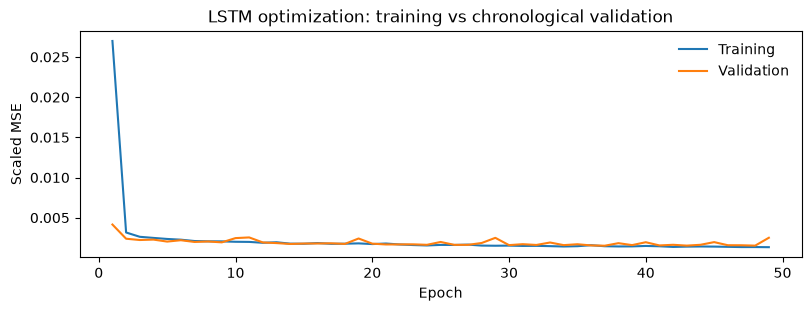

In [5]:
fig, ax = plt.subplots(figsize=(8, 3), layout='constrained')
epochs = range(1, len(history.history['loss']) + 1)
ax.plot(epochs, history.history['loss'], label='Training')
ax.plot(epochs, history.history['val_loss'], label='Validation')
ax.set(xlabel='Epoch', ylabel='Scaled MSE', title='LSTM optimization: training vs chronological validation')
ax.legend(frameon=False)
fig.savefig(RUN_DIR / 'learning_curve.png', dpi=180)
plt.show()
plt.close(fig)

## Held-out errors against persistence
For each test origin, the baseline repeats the most recently observed Close for all seven target days. Inverse scaling restores price units. Report MAE and RMSE separately at each horizon. Positive MAE improvement means lower error than persistence; negative means underperformance. Price-error improvements do not establish profitable trading.

rnn.py:656: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1481.)
  outputs, h_n, c_n = torch._VF.lstm(


,horizon_days,test_windows,lstm_mae_usd,persistence_mae_usd,lstm_rmse_usd,persistence_rmse_usd,mae_improvement_pct
0,1,359,143.887850,83.898909,191.809214,120.612892,-71.501456
1,2,359,172.074491,122.297318,230.665458,169.881050,-40.701769
2,3,359,190.635841,152.413316,250.403978,205.728456,-25.078206
3,4,359,210.757396,172.519193,278.996208,232.170250,-22.164608
4,5,359,236.023063,187.804471,307.042412,255.515189,-25.674890
5,6,359,251.471608,205.225074,321.368344,276.517497,-22.534544
6,7,359,272.760676,223.057501,363.598857,298.509907,-22.282674


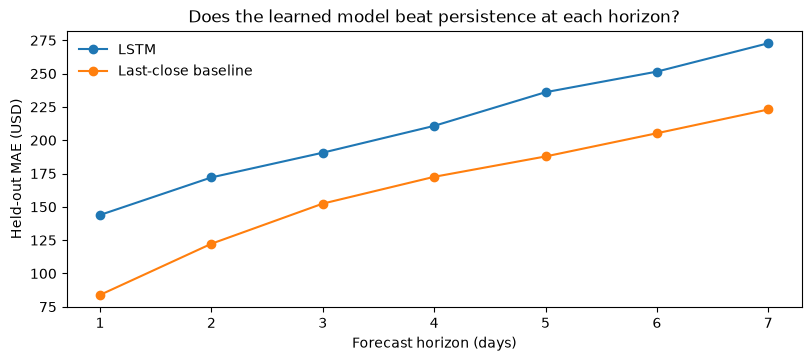

In [6]:
predicted_scaled = model.predict(X[test_mask], batch_size=256, verbose=0)
def unscale_close(values):
    return (values - scaler.min_[close_index]) / scaler.scale_[close_index]
actual = unscale_close(y[test_mask])
predicted = unscale_close(predicted_scaled)
baseline = np.repeat(previous_close[test_mask, None], HORIZON, axis=1)
model_errors, baseline_errors = np.abs(actual-predicted), np.abs(actual-baseline)
metrics = pd.DataFrame({
    'horizon_days': np.arange(1, HORIZON+1),
    'test_windows': int(test_mask.sum()),
    'lstm_mae_usd': model_errors.mean(axis=0),
    'persistence_mae_usd': baseline_errors.mean(axis=0),
    'lstm_rmse_usd': np.sqrt(np.mean((actual-predicted)**2, axis=0)),
    'persistence_rmse_usd': np.sqrt(np.mean((actual-baseline)**2, axis=0)),
})
metrics['mae_improvement_pct'] = 100*(1-metrics['lstm_mae_usd']/metrics['persistence_mae_usd'])
display(metrics)
metrics.to_csv(RUN_DIR / 'held_out_horizon_metrics.csv', index=False)
np.savez_compressed(RUN_DIR / 'held_out_predictions.npz', actual=actual, predicted=predicted,
                    baseline=baseline, target_dates=dates[test_mask])
fig, ax = plt.subplots(figsize=(8, 3.5), layout='constrained')
ax.plot(metrics['horizon_days'], metrics['lstm_mae_usd'], 'o-', label='LSTM')
ax.plot(metrics['horizon_days'], metrics['persistence_mae_usd'], 'o-', label='Last-close baseline')
ax.set(xlabel='Forecast horizon (days)', ylabel='Held-out MAE (USD)',
       title='Does the learned model beat persistence at each horizon?', xticks=range(1, 8))
ax.legend(frameon=False)
fig.savefig(RUN_DIR / 'horizon_mae_vs_baseline.png', dpi=180)
plt.show()
plt.close(fig)

## Disclosed failure case
Inspect the test window with the largest mean absolute LSTM price error over seven horizons. This is a deliberately selected failure, not a random or representative outcome. Compare with persistence, then discuss whether the model missed a sharp move, reverted toward older price levels, or exceeded its training range. Avoid inventing an explanation without inspecting the actual dates and prices.

,actual,lstm,persistence
2025-08-22,4831.348832,3926.335287,4223.209961
2025-08-23,4776.090296,3874.505946,4223.209961
2025-08-24,4779.647427,3888.375178,4223.209961
2025-08-25,4372.987855,3814.277628,4223.209961
2025-08-26,4600.426693,3804.003851,4223.209961
2025-08-27,4503.393073,3854.419695,4223.209961
2025-08-28,4507.177615,3663.393897,4223.209961


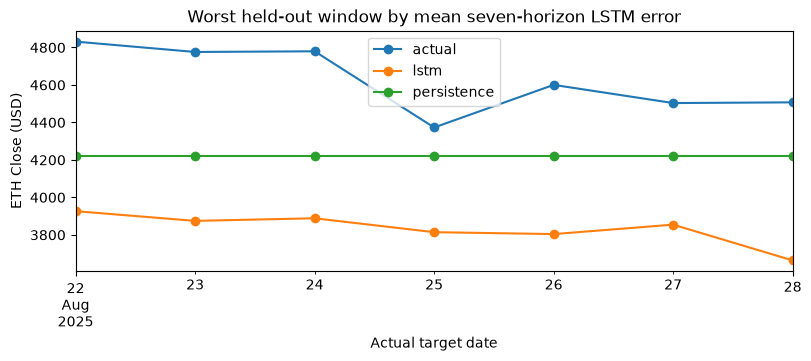

In [7]:
worst_index = int(np.argmax(model_errors.mean(axis=1)))
example_dates = pd.to_datetime(dates[test_mask][worst_index])
example = pd.DataFrame({'actual': actual[worst_index], 'lstm': predicted[worst_index],
                        'persistence': baseline[worst_index]}, index=example_dates)
display(example)
fig, ax = plt.subplots(figsize=(8, 3.5), layout='constrained')
example.plot(ax=ax, marker='o')
ax.set(ylabel='ETH Close (USD)', xlabel='Actual target date', title='Worst held-out window by mean seven-horizon LSTM error')
fig.savefig(RUN_DIR / 'worst_test_window.png', dpi=180)
plt.show()
plt.close(fig)
example.to_csv(RUN_DIR / 'worst_test_window.csv', index_label='target_date')

## Measured findings and limitations
The next cell states the observed baseline comparison without assuming success. This is one architecture and seed on one asset and period. Crypto regimes change, labels overlap across origins, and prices may move outside training ranges. The model does not use news or order-book data. No causal or trading-performance claim follows from these errors. A next experiment should be chosen using training/validation data, with a new held-out period for confirmation.

In [8]:
summary = {
    'experiment': 'new_follow_up_lstm_benchmark_not_original_checkpoint',
    'asset': 'ETH-USD', 'lookback_days': LOOKBACK, 'horizon_days': HORIZON, 'seed': 42,
    'train_windows': int(train_mask.sum()), 'validation_windows': int(validation_mask.sum()),
    'test_windows': int(test_mask.sum()), 'epochs_run': len(history.history['loss']),
    'overall_lstm_mae_usd': float(model_errors.mean()),
    'overall_persistence_mae_usd': float(baseline_errors.mean()),
    'overall_mae_improvement_pct': float(100*(1-model_errors.mean()/baseline_errors.mean())),
    'horizons_better_than_persistence': int((metrics['mae_improvement_pct'] > 0).sum()),
    'keras_version': keras.__version__, 'backend': keras.backend.backend(),
    'torch_version': torch.__version__, 'gpu': torch.cuda.get_device_name(0),
}
(RUN_DIR / 'run_summary.json').write_text(json.dumps(summary, indent=2)+'\n')
print(f"LSTM MAE: ${summary['overall_lstm_mae_usd']:.2f}; persistence: ${summary['overall_persistence_mae_usd']:.2f}.")
print(f"Baseline-relative MAE improvement: {summary['overall_mae_improvement_pct']:+.2f}%.")
print('Horizons with lower error:', summary['horizons_better_than_persistence'], 'of', HORIZON)
model.save(RUN_DIR / 'eth_seven_day_lstm.keras')
joblib.dump(scaler, RUN_DIR / 'training_scaler.pkl')
(RUN_DIR / 'features.json').write_text(json.dumps(FEATURES, indent=2)+'\n')

LSTM MAE: $211.09; persistence: $163.89.
Baseline-relative MAE improvement: -28.80%.
Horizons with lower error: 0 of 7


55

## Interpretation of the completed follow-up run (2026-10-06)

**Decision:** the new LSTM does not justify replacing the last-close baseline. Across **359 forecast origins in 2025**, mean error over all seven horizons is **$211.09**, versus **$163.89** for persistence: **28.80% higher MAE**. It underperforms at every horizon. These overlapping origins are correlated; the count is not a count of independent trials.

**Training:** early stopping ended after **49 epochs** and restored the lowest validation-loss weights from **epoch 37**. The final test period did not control early stopping. Decreasing training loss therefore cannot be presented as improved test forecasting.

**Failure example:** the explicitly selected worst window is **2025-08-22–2025-08-28**. At the origin, the last known Close was **$4223.21**. Actual target prices range from **$4372.99 to $4831.35**, while LSTM forecasts range from **$3663.39 to $3926.34**. Both forecasts miss the upward move; the LSTM also predicts values below the last observed price, increasing its error. OHLCV alone gives no evidence explaining the news or market cause of that move.

**Next development experiment:** compare a model predicting changes relative to the last Close, with simple zero-change and linear baselines, on the training/validation periods. Inspect errors by volatility regime on development data. Avoid selecting settings against the already inspected 2025 test period; use a later untouched period for confirmation. Keep this result separate from the original hackathon's award and deployed integration.
